In [51]:
# 🔧 RETROACTIVELY ADD TEMPERATURE FIELD TO ALL JSON RECORD FILES
# Run this once to update all individual JSON record files

import json
import os
import glob
from pathlib import Path

# Base records directory
records_base = '/Users/hwanda/Desktop/EdenCode/projects/PyCliffordMCP/dev/pauli_string_multiplication/direct_multiplication/records'

# Find all model directories
model_dirs = [d for d in os.listdir(records_base) if os.path.isdir(os.path.join(records_base, d)) and not d.startswith('.')]

print(f"Found model directories: {model_dirs}")

total_files_processed = 0
total_files_updated = 0

for model_dir in model_dirs:
    model_path = os.path.join(records_base, model_dir)
    
    # Find all JSON record files (pattern: record_*.json)
    json_pattern = os.path.join(model_path, 'record_*.json')
    json_files = glob.glob(json_pattern)
    
    if json_files:
        print(f"\n📁 Processing {model_dir}: Found {len(json_files)} JSON files")
        
        updated_count = 0
        for json_file in json_files:
            total_files_processed += 1
            
            try:
                # Read existing JSON
                with open(json_file, 'r') as f:
                    record = json.load(f)
                
                # Check if temperature field already exists
                if 'temperature' in record:
                    continue  # Skip if already exists
                
                # Add temperature field with value 0.0
                record['temperature'] = 0.0
                
                # Write updated JSON directly (no backup)
                with open(json_file, 'w') as f:
                    json.dump(record, f, indent=2)
                
                updated_count += 1
                total_files_updated += 1
                
            except Exception as e:
                print(f"   ❌ Error processing {os.path.basename(json_file)}: {e}")
        
        if updated_count > 0:
            print(f"   ✅ Updated {updated_count} JSON files with temperature=0.0")
        else:
            print(f"   ⚠️  All JSON files already have temperature field")
    else:
        print(f"   📂 No JSON record files found in {model_dir}")

print(f"\n🎉 Summary:")
print(f"   📊 Total files processed: {total_files_processed}")
print(f"   ✅ Files updated: {total_files_updated}")

if total_files_updated > 0:
    print(f"\n💡 All existing JSON records now have temperature=0.0 field added!")
else:
    print(f"\n💡 All JSON files already had temperature field - no updates needed.")


Found model directories: ['gemini-2.5-pro', 'gemini-2.5-flash', 'gemini-2.0-flash']

📁 Processing gemini-2.5-pro: Found 1600 JSON files
   ✅ Updated 1600 JSON files with temperature=0.0

📁 Processing gemini-2.5-flash: Found 1600 JSON files
   ✅ Updated 1600 JSON files with temperature=0.0

📁 Processing gemini-2.0-flash: Found 1200 JSON files
   ✅ Updated 1200 JSON files with temperature=0.0

🎉 Summary:
   📊 Total files processed: 4400
   ✅ Files updated: 4400

💡 All existing JSON records now have temperature=0.0 field added!


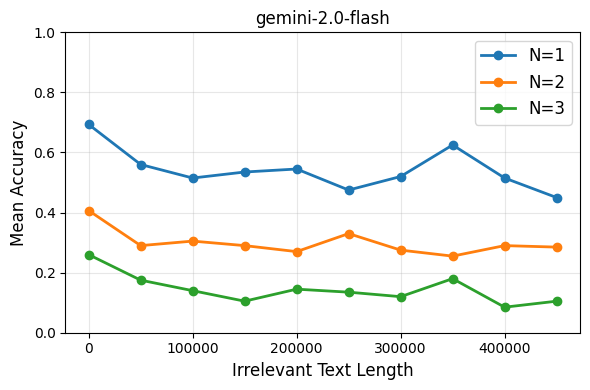

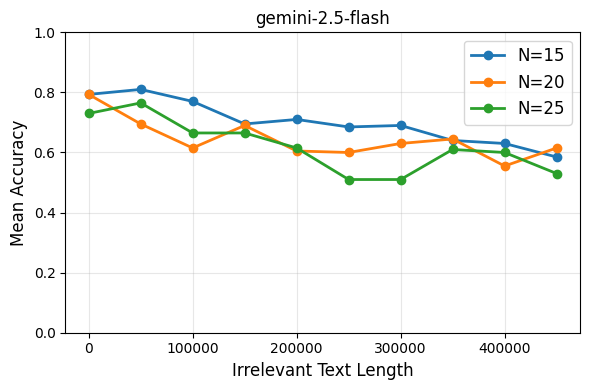

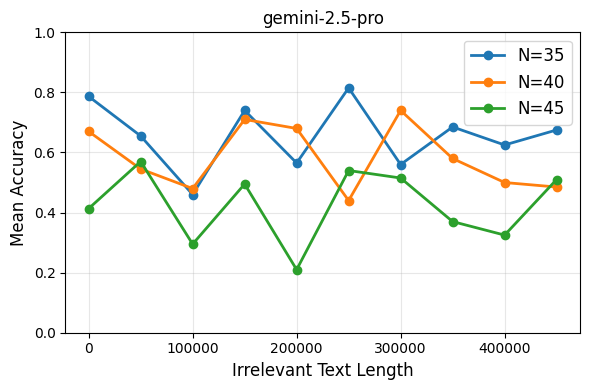

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

model_config = {
    "gemini-2.0-flash": [1, 2, 3],
    "gemini-2.5-flash": [15, 20, 25],
    "gemini-2.5-pro": [35, 40, 45],
}

for model_name, N_values_to_plot in model_config.items():
    # Load CSV file
    csv_path = f'/Users/hwanda/Desktop/EdenCode/projects/PyCliffordMCP/dev/pauli_string_multiplication/direct_multiplication/records/{model_name}/accuracy_summary.csv'
    
    try:
        df = pd.read_csv(csv_path)
        
        # Filter to temperature=0.0 only
        df = df[df['temperature'] == 0.0]
        
        # Create plot
        plt.figure(figsize=(6, 4))
        
        # Plot only the specified N values
        for N in N_values_to_plot:
            # Filter data for this N value
            n_data = df[df['N'] == N]
            
            if len(n_data) > 0:  # Only plot if data exists
                # Group by L_irr and calculate mean accuracy
                grouped = n_data.groupby('L_irr')['accuracy'].mean()
                
                # Plot
                plt.plot(grouped.index, grouped.values, marker='o', label=f'N={N}', linewidth=2)
            else:
                print(f"Warning: No data found for N={N} in {model_name}")
        
        plt.xlabel('Irrelevant Text Length', fontsize=12)
        plt.ylabel('Mean Accuracy', fontsize=12)
        plt.title(f'{model_name}', fontsize=12)
        plt.legend(fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.ylim(0, 1.0)
        plt.tight_layout()
        plt.show()
        
    except FileNotFoundError:
        print(f"❌ File not found: {csv_path}")
    except Exception as e:
        print(f"❌ Error loading {model_name}: {e}")

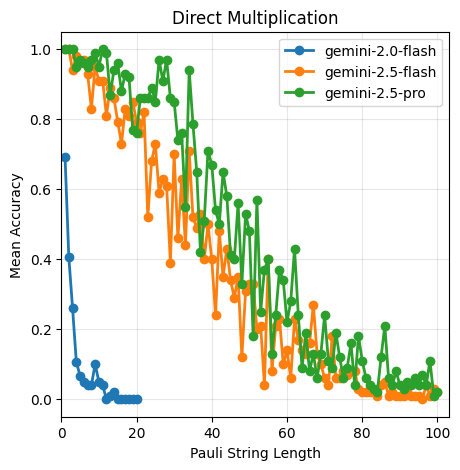

In [53]:
# 🚀 SIMPLEST SOLUTION - Accuracy vs N for different models (L_irr=0 only)

import pandas as pd
import matplotlib.pyplot as plt

# Models to compare
models = ["gemini-2.0-flash", "gemini-2.5-flash", "gemini-2.5-pro"]
SHOW_ERROR_BARS = False  # Set to False to hide error bars

plt.figure(figsize=(5, 5))

for model in models:
    # Load data
    csv_path = f'/Users/hwanda/Desktop/EdenCode/projects/PyCliffordMCP/dev/pauli_string_multiplication/direct_multiplication/records/{model}/accuracy_summary.csv'
    df = pd.read_csv(csv_path)
    
    # Filter to temperature=0.0 and L_irr=0 only
    df_clean = df[(df['temperature'] == 0.0) & (df['L_irr'] == 0)]
    grouped = df_clean.groupby('N')['accuracy'].agg(['mean', 'std'])
    
    # Plot with or without error bars
    if SHOW_ERROR_BARS:
        plt.errorbar(grouped.index, grouped['mean'], yerr=grouped['std'], 
                    marker='o', label=model, linewidth=2, capsize=5)
    else:
        plt.plot(grouped.index, grouped['mean'], marker='o', label=model, linewidth=2)

plt.xlabel('Pauli String Length')
plt.ylabel('Mean Accuracy')
plt.title('Direct Multiplication')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 103)
plt.ylim(-0.05, 1.05)
plt.show()

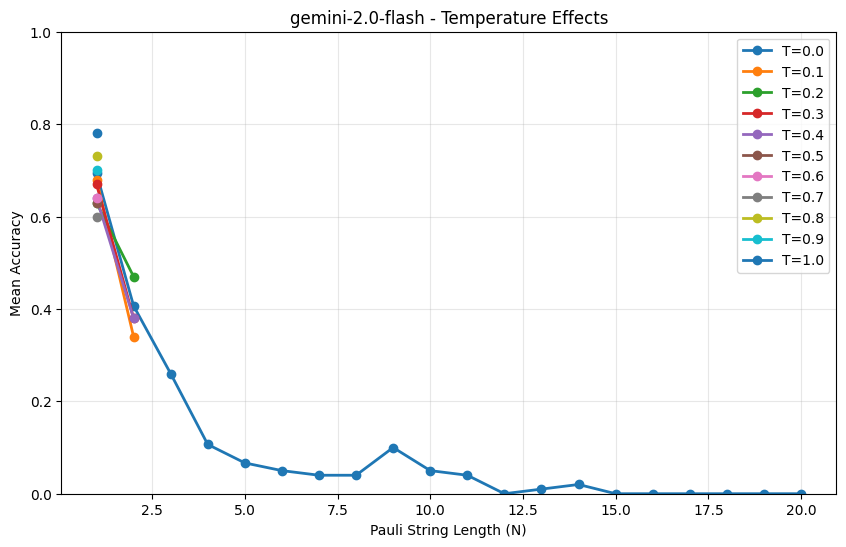

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

# Change this to your model
MODEL_NAME = "gemini-2.0-flash"

# Load data
csv_path = f'/Users/hwanda/Desktop/EdenCode/projects/PyCliffordMCP/dev/pauli_string_multiplication/direct_multiplication/records/{MODEL_NAME}/accuracy_summary.csv'
df = pd.read_csv(csv_path)

# Filter L_irr=0 (no distraction)
df = df[df['L_irr'] == 0]

plt.figure(figsize=(10, 6))

# Plot each temperature
for temp in sorted(df['temperature'].unique()):
    temp_data = df[df['temperature'] == temp]
    grouped = temp_data.groupby('N')['accuracy'].mean()
    plt.plot(grouped.index, grouped.values, marker='o', label=f'T={temp}', linewidth=2)

plt.xlabel('Pauli String Length (N)')
plt.ylabel('Mean Accuracy')
plt.title(f'{MODEL_NAME} - Temperature Effects')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.0)
plt.show()


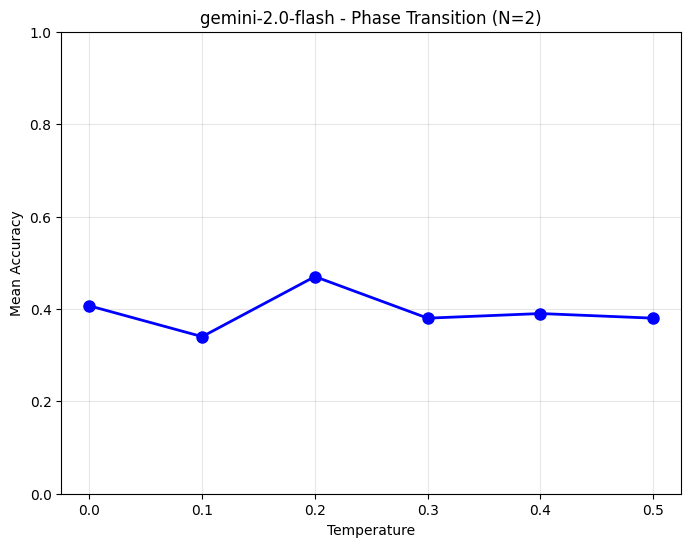

Found 6 temperature points for N=2


In [57]:
import pandas as pd
import matplotlib.pyplot as plt

# Change these to your desired values
MODEL_NAME = "gemini-2.0-flash"
N_VALUE = 2  # Pauli string length to analyze

# Load data
csv_path = f'/Users/hwanda/Desktop/EdenCode/projects/PyCliffordMCP/dev/pauli_string_multiplication/direct_multiplication/records/{MODEL_NAME}/accuracy_summary.csv'
df = pd.read_csv(csv_path)

# Filter for specific N and L_irr=0 (no distraction)
df_filtered = df[(df['N'] == N_VALUE) & (df['L_irr'] == 0)]

plt.figure(figsize=(8, 6))

# Group by temperature and plot
grouped = df_filtered.groupby('temperature')['accuracy'].mean()
plt.plot(grouped.index, grouped.values, marker='o', markersize=8, linewidth=2, color='blue')

plt.xlabel('Temperature')
plt.ylabel('Mean Accuracy') 
plt.title(f'{MODEL_NAME} - Phase Transition (N={N_VALUE})')
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.0)
plt.show()

print(f"Found {len(grouped)} temperature points for N={N_VALUE}")


In [ ]:
# 🔧 RENAME EXISTING JSON FILES TO INCLUDE TEMPERATURE
# Run this once to add temp0.0 to all existing JSON filenames

import os
import glob

# Base records directory
records_base = '/Users/hwanda/Desktop/EdenCode/projects/PyCliffordMCP/dev/pauli_string_multiplication/direct_multiplication/records'

# Find all model directories
model_dirs = [d for d in os.listdir(records_base) if os.path.isdir(os.path.join(records_base, d)) and not d.startswith('.')]

print(f"Found model directories: {model_dirs}")

total_renamed = 0

for model_dir in model_dirs:
    model_path = os.path.join(records_base, model_dir)
    
    # Find JSON files with old naming pattern (without temp)
    old_pattern = os.path.join(model_path, 'record_*.json')
    json_files = glob.glob(old_pattern)
    
    renamed_count = 0
    for old_file in json_files:
        filename = os.path.basename(old_file)
        
        # Skip if already has temp in name
        if '_temp' in filename:
            continue
            
        # Convert old pattern to new pattern
        # Old: record_N5_batch10_L_irr0_iter1_20241201.json
        # New: record_N5_batch10_L_irr0_temp0.0_iter1_20241201.json
        new_filename = filename.replace('_iter', '_temp0.0_iter')
        new_file = os.path.join(model_path, new_filename)
        
        # Rename the file
        os.rename(old_file, new_file)
        renamed_count += 1
        total_renamed += 1
    
    if renamed_count > 0:
        print(f"✅ {model_dir}: Renamed {renamed_count} files")
    else:
        print(f"⚠️  {model_dir}: No files needed renaming")

print(f"\n🎉 Total files renamed: {total_renamed}")
print("All existing JSON files now include temp0.0 in their names!")
